In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

In [6]:
## fetch the data
# download the Samsung's stock data from 2018 to 2026 for good training of model
stock_data = yf.download("005930.KS", start="2018-01-01", end="2026-06-01")

# for prediction, only 'close' price is required
data = stock_data[['Close']].values

training_data_len = int(len(data)*0.8)

/tmp/ipykernel_683/2439207433.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download("005930.KS", start="2018-01-01", end="2026-06-01")
[*********************100%***********************]  1 of 1 completed


In [7]:
## scale the data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [12]:
## prepare training data
train_data = scaled_data[0:training_data_len]

X_train = []
y_train = []

#look at the last 60 days to predict 61st day
for i in range(60, len(train_data)):
    X_train.append(train_data[i-60:i, 0]) # FEATURES: 60 days
    y_train.append(train_data[i, 0]) # target: 61 day

X_train, y_train = np.array(X_train), np.array(y_train) #for deep learning model to process train lists convert 'em to numpy array

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1)) #reshape to 3d for lstm


In [13]:
model = Sequential()

model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1))) # return_sequences=True  passes data to next  layer
model.add(Dropout(0.2)) # Dropout is used to turn off 20% of neurons to prevent overfitting

model.add(LSTM(units=50, return_sequences=False)) #return_sequences=False as standard dense layer will be used next
model.add(Dropout(0.2))

model.add(Dense(units=25)) # standard neural network layer for final numbers to go down to a single prediction
model.add(Dense(units=1)) # Output Layer

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
## Compilation and training
model.compile(optimizer='adam', loss='mean_squared_error') #higly efficient optimizer=adam, mse=for predicting exact values

model.fit(X_train, y_train, batch_size=32, epochs=10)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 6.5491e-04
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.2604e-04
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.0071e-04
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 9.3846e-05
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.0234e-04
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 8.7467e-05
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.3732e-05
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 7.2903e-05
Epoch 9/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 6.6868e-05
Epoch 10/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.2248e-05


In [15]:
## Prepare testing data
test_data = scaled_data[training_data_len-60:] #need 60 days of data for prediction

X_test = []
y_test = data[training_data_len:] #actual values

for i in range(60, len(test_data)):
    X_test.append(test_data[i-60:i, 0])

X_test = np. array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [16]:
## Make predictions
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions) # to convert back the scaled predictions to actual form

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [17]:
## Evaluate the error
rmse = np.sqrt(np.mean(((predictions - y_test)**2))) #Root Mean Square Error tells how far is prediction from actual value
print(f'Average error (RMSE): {rmse}')

Average error (RMSE): 12769.118519167903


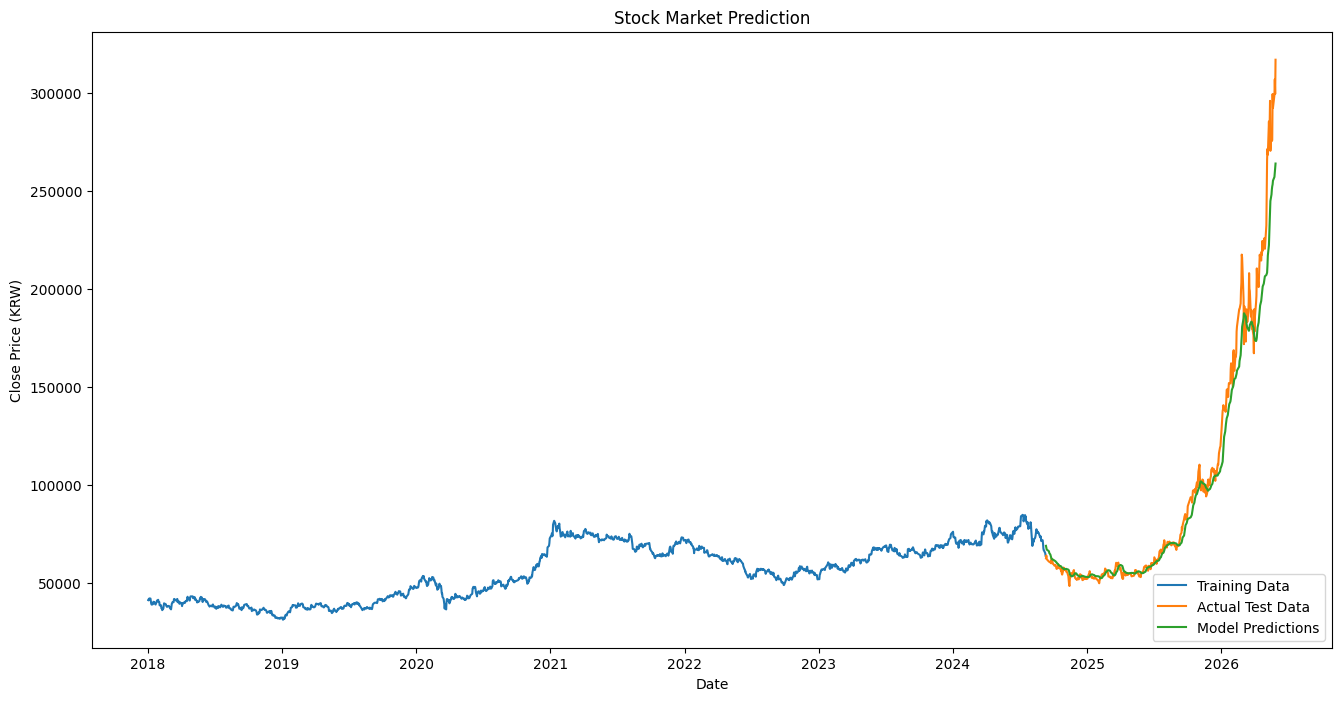

In [19]:
## Visualize the Results
train = stock_data[:training_data_len].copy()
valid = stock_data[training_data_len:].copy()
valid['Predictions'] = predictions

plt.figure(figsize=(16,8))
plt.title('Stock Market Prediction')
plt.xlabel('Date')
plt.ylabel('Close Price (KRW)')
plt.plot(train['Close'], label='Training Data')
plt.plot(valid['Close'], label='Actual Test Data')
plt.plot(valid['Predictions'], label='Model Predictions')
plt.legend(loc='lower right')
plt.show()